In [1]:
import os
import random
import time
from datetime import datetime

import numpy as np
import torch

from config import Config
from data import load_mcmaze, gaussian_smooth, make_windows, train_val_split
from model import MLP
from train import train


In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [3]:
cfg = Config()

print("Loading MC_Maze data …")
spikes_raw, bin_width_s, trial_info, time_index_s = load_mcmaze(cfg.nwb_path, cfg.bin_ms)

N = spikes_raw.shape[0]
print(f"  Channels: {N}  |  Bin width: {cfg.bin_ms} ms  |  Trials: {len(trial_info)}")

sigma_samples = round((cfg.sigma_ms * 1e-3) / bin_width_s)
print(f"  Gaussian smoothing sigma: {cfg.sigma_ms} ms = {sigma_samples} bins")
X_smooth = gaussian_smooth(spikes_raw, sigma_samples)

print(f"Windowing ({cfg.window_strategy}, align={cfg.align_field}, "
        f"pre={cfg.pre_ms}ms, T={cfg.window_size}) …")
windows = make_windows(
    X_smooth, trial_info, time_index_s, bin_width_s,
    strategy=cfg.window_strategy, window_size=cfg.window_size,
    align_field=cfg.align_field, pre_ms=cfg.pre_ms,
)
print(f"  Windows shape: {windows.shape}  (K, N, T)")


Loading MC_Maze data …


ValueError: too many values to unpack (expected 4)

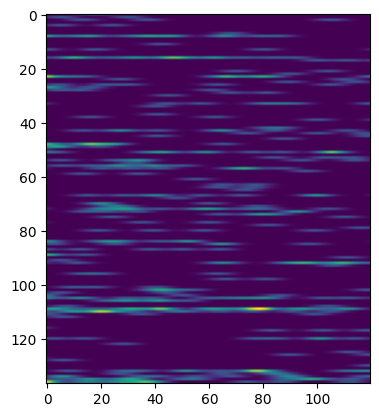

In [49]:
import matplotlib.pyplot as plt
plt.imshow(windows[5,:,:])

In [39]:
windows[0,0,:]

array([1.6023391e-01, 1.7195748e-01, 1.7603889e-01, 1.7195748e-01,
       1.6023391e-01, 1.4233434e-01, 1.2039999e-01, 9.6857116e-02,
       7.3993042e-02, 5.3599082e-02, 3.6762774e-02, 2.3843564e-02,
       1.4606221e-02, 8.4424736e-03, 4.6004085e-03, 2.3616231e-03,
       1.1414600e-03, 5.0727994e-04, 2.1817839e-04, 8.8152039e-05,
       3.3458742e-05, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e

In [11]:
from nlb_tools.nwb_interface import NWBDataset

"""Load NLB MC_Maze NWB, resample to bin_ms, return spike array and trial info.

Returns
-------
spikes_raw : np.ndarray, shape (N, T_total), float32
    Raw spike counts. NaN entries (inter-trial gaps) are filled with 0.
bin_width_s : float
    Bin duration in seconds.
trial_info : pd.DataFrame
    Trial table with all NWB fields converted to seconds, plus a
    `reach_angle` column (radians ∈ [-π, π]) computed as the angle of
    the active target's position when available.
time_index_s : np.ndarray
    Global time index in seconds for mapping trial times → bin indices.
"""
_TIME_COLS = [
    "start_time", "end_time", "stop_time",
    "target_on_time", "go_cue_time", "move_onset_time",
]

ds = NWBDataset(cfg.nwb_path)

# nlb_tools' resample() succeeds at downsampling but raises a pandas
# freq-set error on data with inter-trial gaps. Suppress and finish the
# bookkeeping it skipped.
try:
    ds.resample(cfg.bin_ms)
except ValueError:
    pass
ds.bin_width = cfg.bin_ms

spikes_df = ds.data["spikes"]                          # (T_total, N)
spikes_raw = spikes_df.values.T.astype(np.float32)     # (N, T_total)
spikes_raw = np.nan_to_num(spikes_raw, nan=0.0)

bin_width_s = cfg.bin_ms * 1e-3
trial_info = ds.trial_info.copy()

for col in _TIME_COLS:
    if col in trial_info.columns:
        delta = trial_info[col]
        if hasattr(delta, "dt"):
            trial_info[col] = delta.dt.total_seconds().values
        elif np.issubdtype(delta.dtype, np.timedelta64):
            trial_info[col] = delta.values.astype("float64") / 1e9

time_index_s = spikes_df.index.values
if np.issubdtype(time_index_s.dtype, np.timedelta64):
    time_index_s = time_index_s.astype("float64") / 1e9
else:
    time_index_s = time_index_s.astype("float64")

# Reach angle for visualisation. Two layouts in the wild:
#   NLB MC_Maze (Jenkins): `target_pos` is a per-row (n_targets, 2) array
#     and `active_target` is the index of the goal.
#   Indy/Sabes:            `target_pos` and `cursor_pos` are continuous
#     signals in ds.data; angle = arctan2(target − cursor at start).
if "target_pos" in trial_info.columns and "active_target" in trial_info.columns:
    angles = np.empty(len(trial_info), dtype=np.float64)
    for k, (_, row) in enumerate(trial_info.iterrows()):
        tgt_pos = np.asarray(row["target_pos"])    # (n_targets, 2)
        act_idx = int(row["active_target"])
        x, y = tgt_pos[act_idx]
        angles[k] = np.arctan2(y, x)
    trial_info["reach_angle"] = angles
elif {"target_pos", "cursor_pos"}.issubset(ds.data.columns.get_level_values(0)):
    target_xy = ds.data["target_pos"][["x", "y"]].values
    cursor_xy = ds.data["cursor_pos"][["x", "y"]].values
    starts = trial_info["start_time"].values.astype("float64")
    idx = np.searchsorted(time_index_s, starts).clip(0, len(time_index_s) - 1)
    delta = target_xy[idx] - cursor_xy[idx]
    trial_info["reach_angle"] = np.arctan2(delta[:, 1], delta[:, 0])


In [13]:
ds = NWBDataset(cfg.nwb_path)

In [ ]:
ds.shape

In [28]:
np.count_nonzero(np.isnan(np.array(ds.data.hand_pos.x)))

np.int64(142381)

In [31]:
ds.trial_info

,trial_id,start_time,end_time,trial_type,trial_version,maze_id,success,target_on_time,go_cue_time,move_onset_time,rt,delay,num_targets,target_pos,num_barriers,barrier_pos,active_target,split
0,0,0 days 00:00:00,0 days 00:00:03.321000,25,2,84,True,0 days 00:00:00.880000,0 days 00:00:01.478000,0 days 00:00:01.905000,427,598,3,"[[-111, -82], [-108, 81], [118, 72]]",8,"[[69, 31, 14, 99], [69, 54, 5, 101], [-62, -48...",2,val
1,1,0 days 00:00:03.400000,0 days 00:00:06.521000,3,1,3,True,0 days 00:00:04.291000,0 days 00:00:04.739000,0 days 00:00:05.280000,541,448,1,"[[-116, -5]]",6,"[[-69, -16, 13, 69], [-120, -62, 83, 15], [95,...",0,val
2,2,0 days 00:00:06.600000,0 days 00:00:09.856000,22,1,66,True,0 days 00:00:07.471000,0 days 00:00:07.969000,0 days 00:00:08.346000,377,498,1,"[[-82, -86]]",9,"[[34, -41, 86, 8], [9, -42, 33, 19], [7, -41, ...",0,train
3,3,0 days 00:00:09.900000,0 days 00:00:12.946000,29,2,100,True,0 days 00:00:10.853000,0 days 00:00:11.335000,0 days 00:00:11.752000,417,482,3,"[[-109, 2], [2, 82], [132, -65]]",9,"[[-9, 52, 43, 8], [-50, 91, 14, 64], [-133, -5...",1,train
4,4,0 days 00:00:13,0 days 00:00:15.481000,21,0,65,True,0 days 00:00:13.687000,0 days 00:00:14.235000,0 days 00:00:14.507000,272,548,1,"[[27, 82]]",0,[],0,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2290,2290,0 days 01:55:36.600000,0 days 01:55:39.796000,34,1,91,True,0 days 01:55:37.362000,0 days 01:55:38.277000,0 days 01:55:38.585000,308,915,1,"[[116, -77]]",7,"[[66, -43, 30, 9], [-66, 1, 11, 70], [-35, 50,...",0,train
2291,2291,0 days 01:55:39.900000,0 days 01:55:42.736000,15,1,75,True,0 days 01:55:40.717000,0 days 01:55:41.265000,0 days 01:55:41.641000,376,548,1,"[[133, -81]]",9,"[[-33, 47, 37, 6], [-77, 48, 61, 11], [-64, -2...",0,train
2292,2292,0 days 01:55:42.800000,0 days 01:55:45.766000,23,0,67,True,0 days 01:55:43.465000,0 days 01:55:44.396000,0 days 01:55:44.714000,318,931,1,"[[94, -86]]",0,[],0,train
2293,2293,0 days 01:55:45.800000,0 days 01:55:49.201000,25,2,84,True,0 days 01:55:46.631000,0 days 01:55:46.663000,0 days 01:55:47.616000,953,32,3,"[[-111, -82], [-108, 81], [118, 72]]",8,"[[69, 31, 14, 99], [69, 54, 5, 101], [-62, -48...",2,val


In [32]:
ds.data

/Users/omomalley03/Documents/Dissertation/POC_MLP/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


signal_type            cursor_pos           eye_pos       hand_pos             \
channel                         x         y       x    y         x          y   
clock_time                                                                      
0 days 00:00:00         -0.900000 -5.700000     7.2  2.0 -0.714908 -40.526123   
0 days 00:00:00.001000  -0.907457 -5.687027     7.2  2.1 -0.717532 -40.496146   
0 days 00:00:00.002000  -0.912768 -5.672115     7.6  1.2 -0.720323 -40.464968   
0 days 00:00:00.003000  -0.914050 -5.653433     7.4  1.4 -0.723278 -40.432658   
0 days 00:00:00.004000  -0.909980 -5.629617     7.4  3.6 -0.726362 -40.399272   
...                           ...       ...     ...  ...       ...        ...   
0 days 01:55:49.295000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.296000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.297000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.298000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.299000        NaN       NaN     NaN  NaN       NaN        NaN   

signal_type             hand_vel            heldout_spikes       ... spikes  \
channel                        x          y           1021 1022  ...   2821   
clock_time                                                       ...          
0 days 00:00:00        -2.624567  29.977111            0.0  0.0  ...    0.0   
0 days 00:00:00.001000 -2.707321  30.577662            0.0  0.0  ...    0.0   
0 days 00:00:00.002000 -2.872729  31.744164            0.0  0.0  ...    0.0   
0 days 00:00:00.003000 -3.019660  32.847931            0.0  0.0  ...    0.0   
0 days 00:00:00.004000 -3.059403  33.895227            0.0  0.0  ...    0.0   
...                          ...        ...            ...  ...  ...    ...   
0 days 01:55:49.295000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.296000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.297000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.298000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.299000       NaN        NaN            NaN  NaN  ...    NaN   

signal_type                                                          
channel                2842 2861 2862 2871 2881 2911 2931 2951 2961  
clock_time                                                           
0 days 00:00:00         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.001000  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  
0 days 00:00:00.002000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.003000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.004000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...                     ...  ...  ...  ...  ...  ...  ...  ...  ...  
0 days 01:55:49.295000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.296000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.297000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.298000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.299000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[6952301 rows x 190 columns]

In [121]:
import gc
gc.collect()
dataset = NWBDataset("../Data/000128/sub-Jenkins/", "*train", split_heldout=False)

In [33]:
ds.data

/Users/omomalley03/Documents/Dissertation/POC_MLP/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


signal_type            cursor_pos           eye_pos       hand_pos             \
channel                         x         y       x    y         x          y   
clock_time                                                                      
0 days 00:00:00         -0.900000 -5.700000     7.2  2.0 -0.714908 -40.526123   
0 days 00:00:00.001000  -0.907457 -5.687027     7.2  2.1 -0.717532 -40.496146   
0 days 00:00:00.002000  -0.912768 -5.672115     7.6  1.2 -0.720323 -40.464968   
0 days 00:00:00.003000  -0.914050 -5.653433     7.4  1.4 -0.723278 -40.432658   
0 days 00:00:00.004000  -0.909980 -5.629617     7.4  3.6 -0.726362 -40.399272   
...                           ...       ...     ...  ...       ...        ...   
0 days 01:55:49.295000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.296000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.297000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.298000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 01:55:49.299000        NaN       NaN     NaN  NaN       NaN        NaN   

signal_type             hand_vel            heldout_spikes       ... spikes  \
channel                        x          y           1021 1022  ...   2821   
clock_time                                                       ...          
0 days 00:00:00        -2.624567  29.977111            0.0  0.0  ...    0.0   
0 days 00:00:00.001000 -2.707321  30.577662            0.0  0.0  ...    0.0   
0 days 00:00:00.002000 -2.872729  31.744164            0.0  0.0  ...    0.0   
0 days 00:00:00.003000 -3.019660  32.847931            0.0  0.0  ...    0.0   
0 days 00:00:00.004000 -3.059403  33.895227            0.0  0.0  ...    0.0   
...                          ...        ...            ...  ...  ...    ...   
0 days 01:55:49.295000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.296000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.297000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.298000       NaN        NaN            NaN  NaN  ...    NaN   
0 days 01:55:49.299000       NaN        NaN            NaN  NaN  ...    NaN   

signal_type                                                          
channel                2842 2861 2862 2871 2881 2911 2931 2951 2961  
clock_time                                                           
0 days 00:00:00         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.001000  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  
0 days 00:00:00.002000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.003000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.004000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...                     ...  ...  ...  ...  ...  ...  ...  ...  ...  
0 days 01:55:49.295000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.296000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.297000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.298000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 01:55:49.299000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[6952301 rows x 190 columns]

In [117]:
conds = dataset.trial_info.set_index(['trial_type', 'trial_version']).index.unique().tolist()

In [118]:
dataset.trial_info.end_time[0].microseconds/5000

64.2

In [91]:
dataset.trial_info

,trial_id,start_time,end_time,trial_type,trial_version,maze_id,success,target_on_time,go_cue_time,move_onset_time,rt,delay,num_targets,target_pos,num_barriers,barrier_pos,active_target,split
0,0,0 days 00:00:00,0 days 00:00:03.321000,25,2,84,True,0 days 00:00:00.880000,0 days 00:00:01.478000,0 days 00:00:01.905000,427,598,3,"[[-111, -82], [-108, 81], [118, 72]]",8,"[[69, 31, 14, 99], [69, 54, 5, 101], [-62, -48...",2,val
1,1,0 days 00:00:03.400000,0 days 00:00:06.521000,3,1,3,True,0 days 00:00:04.291000,0 days 00:00:04.739000,0 days 00:00:05.280000,541,448,1,"[[-116, -5]]",6,"[[-69, -16, 13, 69], [-120, -62, 83, 15], [95,...",0,val
2,2,0 days 00:00:06.600000,0 days 00:00:09.856000,22,1,66,True,0 days 00:00:07.471000,0 days 00:00:07.969000,0 days 00:00:08.346000,377,498,1,"[[-82, -86]]",9,"[[34, -41, 86, 8], [9, -42, 33, 19], [7, -41, ...",0,train
3,3,0 days 00:00:09.900000,0 days 00:00:12.946000,29,2,100,True,0 days 00:00:10.853000,0 days 00:00:11.335000,0 days 00:00:11.752000,417,482,3,"[[-109, 2], [2, 82], [132, -65]]",9,"[[-9, 52, 43, 8], [-50, 91, 14, 64], [-133, -5...",1,train
4,4,0 days 00:00:13,0 days 00:00:15.481000,21,0,65,True,0 days 00:00:13.687000,0 days 00:00:14.235000,0 days 00:00:14.507000,272,548,1,"[[27, 82]]",0,[],0,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2290,2290,0 days 01:55:36.600000,0 days 01:55:39.796000,34,1,91,True,0 days 01:55:37.362000,0 days 01:55:38.277000,0 days 01:55:38.585000,308,915,1,"[[116, -77]]",7,"[[66, -43, 30, 9], [-66, 1, 11, 70], [-35, 50,...",0,train
2291,2291,0 days 01:55:39.900000,0 days 01:55:42.736000,15,1,75,True,0 days 01:55:40.717000,0 days 01:55:41.265000,0 days 01:55:41.641000,376,548,1,"[[133, -81]]",9,"[[-33, 47, 37, 6], [-77, 48, 61, 11], [-64, -2...",0,train
2292,2292,0 days 01:55:42.800000,0 days 01:55:45.766000,23,0,67,True,0 days 01:55:43.465000,0 days 01:55:44.396000,0 days 01:55:44.714000,318,931,1,"[[94, -86]]",0,[],0,train
2293,2293,0 days 01:55:45.800000,0 days 01:55:49.201000,25,2,84,True,0 days 01:55:46.631000,0 days 01:55:46.663000,0 days 01:55:47.616000,953,32,3,"[[-111, -82], [-108, 81], [118, 72]]",8,"[[69, 31, 14, 99], [69, 54, 5, 101], [-62, -48...",2,val


In [ ]:
conds = dataset.trial_info.set_index(['trial_type', 'trial_version']).index.unique().tolist()

In [ ]:
plt.plot(dataset.data.hand_pos.x[:],dataset.data.hand_pos.x)

clock_time
0 days 00:00:00          -0.430048
0 days 00:00:00.005000   -0.790714
0 days 00:00:00.010000   -0.710433
0 days 00:00:00.015000   -0.772215
0 days 00:00:00.020000   -0.721376
                            ...   
0 days 01:55:49.279000         NaN
0 days 01:55:49.284000         NaN
0 days 01:55:49.289000         NaN
0 days 01:55:49.294000         NaN
0 days 01:55:49.299000         NaN
Name: x, Length: 1390461, dtype: float64

Sampling interval: 0 days 00:00:00.005000
Skipped (25, 2): ValueError: cannot add indices of unequal length
Skipped (3, 1): ValueError: cannot add indices of unequal length
Skipped (22, 1): ValueError: cannot add indices of unequal length
Skipped (29, 2): ValueError: cannot add indices of unequal length
Skipped (21, 0): ValueError: cannot add indices of unequal length
Skipped (2, 2): ValueError: cannot add indices of unequal length
Skipped (16, 1): ValueError: cannot add indices of unequal length
Skipped (25, 1): ValueError: cannot add indices of unequal length
Skipped (23, 0): ValueError: cannot add indices of unequal length
Skipped (13, 0): ValueError: cannot add indices of unequal length
Skipped (3, 2): ValueError: cannot add indices of unequal length
Skipped (7, 2): ValueError: cannot add indices of unequal length
Skipped (13, 1): ValueError: cannot add indices of unequal length
Skipped (24, 1): ValueError: cannot add indices of unequal length
Skipped (35, 1): ValueError: cannot ad

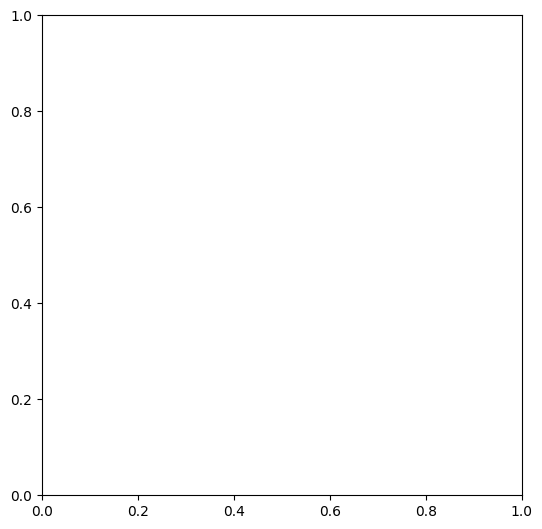

In [90]:
## Plot trial-averaged reaches

conds = dataset.trial_info.set_index(['trial_type', 'trial_version']).index.unique().tolist()

# Infer the sampling interval from the data index
dt = (dataset.data.index[1] - dataset.data.index[0])
print(f"Sampling interval: {dt}")

counter = 0
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

for cond in conds:
    mask = np.all(dataset.trial_info[['trial_type', 'trial_version']] == cond, axis=1)

    try:
        trial_data = dataset.make_trial_data(
            align_field='move_onset_time',
            align_range=(-0.5, 0.5),
            margin=(-dt, -dt),       # pull both endpoints one sample inward
            ignored_trials=(~mask),
            allow_nans=True
        )
    except Exception as e:
        print(f"Skipped {cond}: {type(e).__name__}: {e}")
        continue

    if trial_data is None or trial_data.empty:
        print(f"Empty trial_data for {cond}")
        continue

    # Check hand_pos columns exist
    hand_cols = [c for c in trial_data.columns if 'hand_pos' in str(c)]
    if not hand_cols:
        print(f"No hand_pos columns for {cond}. Columns: {trial_data.columns.tolist()[:10]}")
        break

    traj = trial_data.groupby('align_time')[[('hand_pos', 'x'), ('hand_pos', 'y')]].mean().to_numpy()

    active_target = dataset.trial_info[mask].target_pos.iloc[0][
        dataset.trial_info[mask].active_target.iloc[0]
    ]
    reach_angle = np.arctan2(*active_target[::-1])

    plt.plot(traj[:, 0], traj[:, 1], linewidth=0.7,
             color=plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5))
    counter += 1

print(f"Plotted {counter} conditions")
plt.show()

KeyError: Timedelta('0 days 00:00:03.320999')

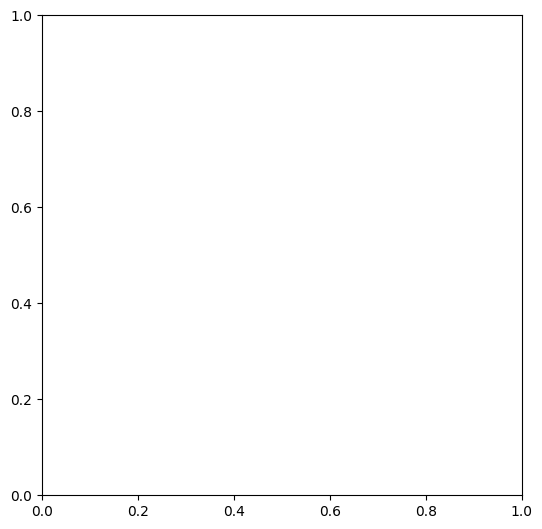

In [14]:
## Plot trial-averaged reaches

# Find unique conditions
conds = dataset.trial_info.set_index(['trial_type', 'trial_version']).index.unique().tolist()

counter = 0
# Initialize plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# Loop over conditions and compute average trajectory
for cond in conds:
    # Find trials in condition
    mask = np.all(dataset.trial_info[['trial_type', 'trial_version']] == cond, axis=1)
    # print(mask.sum())               # print the number of trials that satisfy the condition
    # Extract trial data
    trial_data = dataset.make_trial_data(align_field = 'move_onset_time', ignored_trials = (~mask))
    # Average hand position across trials
    traj = trial_data.groupby('align_time')[[('hand_pos', 'x'), ('hand_pos', 'y')]].mean().to_numpy()
    # Determing reach ange for color
    active_target = dataset.trial_info[mask].target_pos.iloc[0][dataset.trial_info[mask].active_target.iloc[0]]
    reach_angle = np.arctan2(*active_target[::-1])
    # Plot reach
    plt.plot(traj[:, 0], traj[:, 1], linewidth=0.7, color=plt.cm.hsv(reach_angle/(2*np.pi) + 0.5))
    counter += 1
# print(counter)
# plt.axis('off')
plt.show()

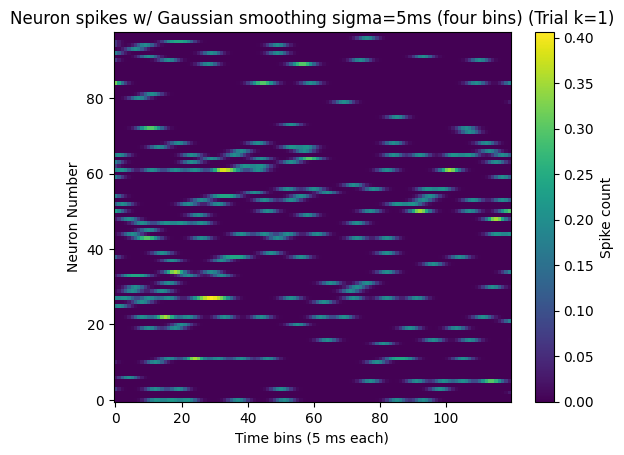

In [6]:
plt.imshow(windows[1,:,:], aspect="auto", origin="lower")
plt.xlabel("Time bins ({} ms each)".format(cfg.bin_ms))
plt.ylabel("Neuron Number")
plt.title("Neuron spikes w/ Gaussian smoothing sigma=5ms (four bins) (Trial k=1)")
plt.colorbar(label="Spike count")
plt.show()